Image Compression using K-Means Clustering

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import cv2
import os

In [23]:
image_path = "Multi-colored-illustration.jpg"

# Verify the file exists
if not os.path.exists(image_path):
    print(f"Error: File not found at {image_path}")
else:
    print(f"Image found: {image_path}")

Image found: Multi-colored-illustration.jpg


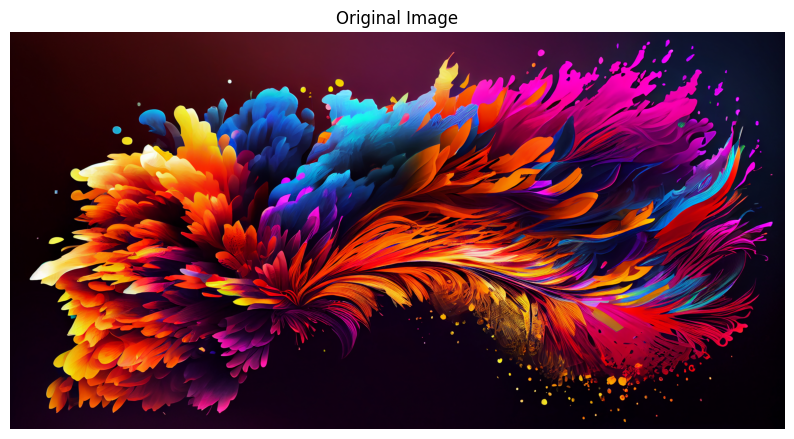

Original Image Shape: (2867, 5600, 3)
Original Image Size: 48165600 pixels


In [16]:
# (In BGR format)
original_image = cv2.imread(image_path)

# Convert BGR to RGB for proper display
original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(original_image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

print(f"Original Image Shape: {original_image_rgb.shape}")
print(f"Original Image Size: {original_image_rgb.shape[0] * original_image_rgb.shape[1] * original_image_rgb.shape[2]} pixels")

Compress Image using K-Means Clustering

In [17]:
# Set the number of clusters (colors) for compression
n_clusters = 32  # ( 8, 16, 32, 64, etc.)

print(f"Compressing image to {n_clusters} colors using K-Means clustering...")

# Reshape image to 2D array of pixels (each pixel is 3 values: R, G, B)
pixels = original_image_rgb.reshape(-1, 3)
print(f"Total pixels: {pixels.shape[0]}")

# Apply K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(pixels)

# Get cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print(f"Compression complete!")
print(f"Number of unique colors reduced from {len(np.unique(pixels, axis=0))} to {n_clusters}")

Compressing image to 32 colors using K-Means clustering...
Total pixels: 16055200
Compression complete!
Number of unique colors reduced from 1040190 to 32


Decompress and Display Compressed Image

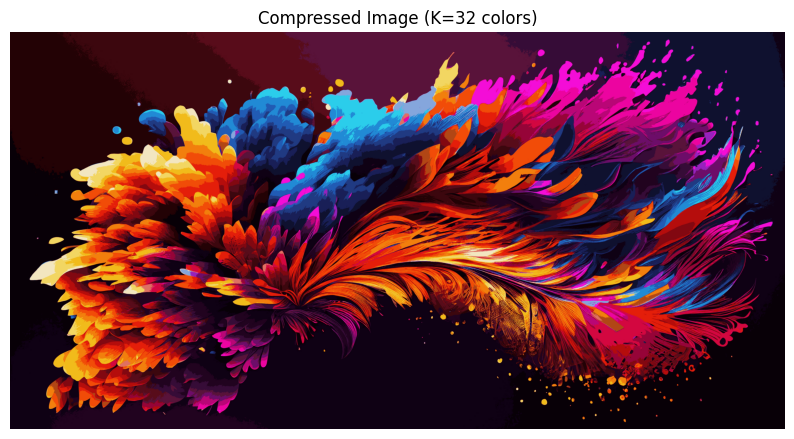

Compressed Image Shape: (2867, 5600, 3)


In [18]:
# Reconstruct the image by replacing each pixel with its cluster centroid
compressed_pixels = centroids[labels]

# Reshape back to original image dimensions
compressed_image = compressed_pixels.reshape(original_image_rgb.shape)

# Convert to uint8 format for display
compressed_image = np.uint8(compressed_image)

# Display compressed image
plt.figure(figsize=(10, 6))
plt.imshow(compressed_image)
plt.title(f"Compressed Image (K={n_clusters} colors)")
plt.axis('off')
plt.show()

print(f"Compressed Image Shape: {compressed_image.shape}")

Side-by-Side Comparison

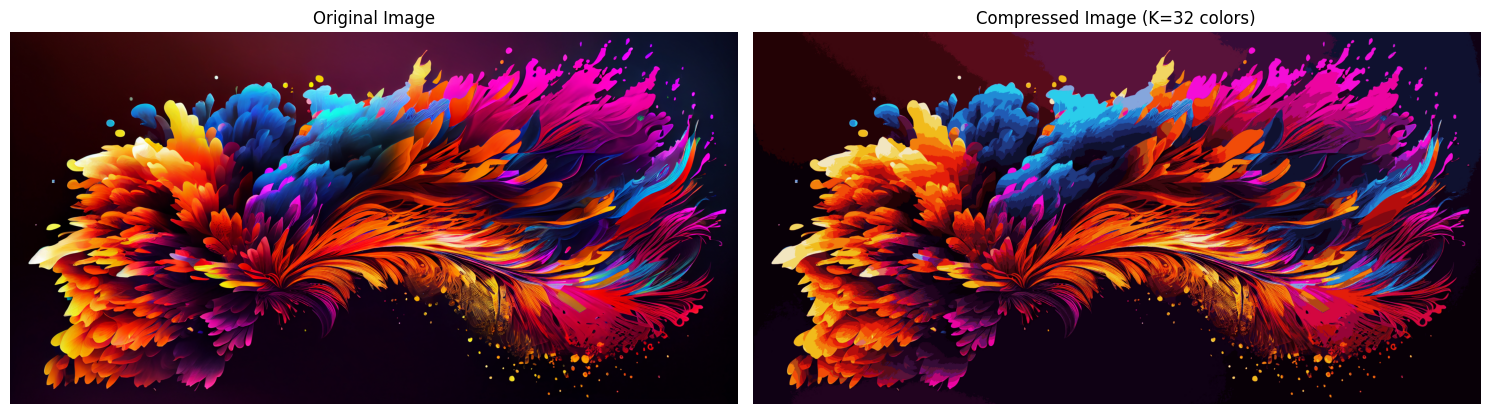

In [19]:
# Display original and compressed images side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(original_image_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(compressed_image)
axes[1].set_title(f"Compressed Image (K={n_clusters} colors)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Compression Statistics

**Important Note:** K-Means reduces the number of colors (data compression), but the actual file size depends on the image format and encoding used when saving.

In [20]:
# Calculate Mean Squared Error (MSE) between original and compressed
mse = np.mean((original_image_rgb - compressed_image) ** 2)

# Calculate PSNR (Peak Signal-to-Noise Ratio) - higher is better
if mse > 0:
    psnr = 20 * np.log10(255.0 / np.sqrt(mse))
else:
    psnr = float('inf')

# Calculate compression ratio based on color information
original_colors = len(np.unique(pixels, axis=0))
compressed_colors = n_clusters
color_compression_ratio = original_colors / compressed_colors

# Calculate in-memory data size comparison
# Original: each pixel stores unique RGB values (potentially millions of colors)
# Compressed: each pixel references one of K centroids
original_data_size = pixels.nbytes  # Raw pixel data in bytes
compressed_data_size = labels.nbytes + centroids.nbytes  # Labels + centroids

actual_compression_ratio = original_data_size / compressed_data_size

print("=" * 60)
print("COMPRESSION STATISTICS")
print("=" * 60)
print(f"Image dimensions: {original_image_rgb.shape[0]} x {original_image_rgb.shape[1]}")
print(f"Total pixels: {pixels.shape[0]:,}")
print()
print("COLOR COMPRESSION:")
print(f"  Original unique colors: {original_colors:,}")
print(f"  Compressed to: {compressed_colors} colors")
print(f"  Color reduction ratio: {color_compression_ratio:.2f}x")
print()
print("IN-MEMORY DATA SIZE:")
print(f"  Original data size: {original_data_size:,} bytes ({original_data_size/1024:.2f} KB)")
print(f"  Compressed data size: {compressed_data_size:,} bytes ({compressed_data_size/1024:.2f} KB)")
print(f"  Actual compression ratio: {actual_compression_ratio:.2f}x")
print(f"  Space saved: {(1 - compressed_data_size/original_data_size)*100:.2f}%")
print()
print("QUALITY METRICS:")
print(f"  Mean Squared Error (MSE): {mse:.2f}")
print(f"  Peak Signal-to-Noise Ratio (PSNR): {psnr:.2f} dB")
print("=" * 60)

COMPRESSION STATISTICS
Image dimensions: 2867 x 5600
Total pixels: 16,055,200

COLOR COMPRESSION:
  Original unique colors: 1,040,190
  Compressed to: 32 colors
  Color reduction ratio: 32505.94x

IN-MEMORY DATA SIZE:
  Original data size: 48,165,600 bytes (47036.72 KB)
  Compressed data size: 64,221,568 bytes (62716.38 KB)
  Actual compression ratio: 0.75x
  Space saved: -33.33%

QUALITY METRICS:
  Mean Squared Error (MSE): 48.36
  Peak Signal-to-Noise Ratio (PSNR): 31.29 dB


Display Color Palette

Show the color palette used in the compressed image (cluster centroids):

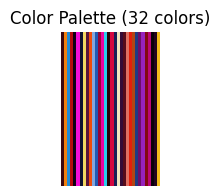


Cluster Centroids (RGB values):
Color 1: RGB(60, 7, 14)
Color 2: RGB(242, 127, 13)
Color 3: RGB(33, 138, 213)
Color 4: RGB(181, 13, 12)
Color 5: RGB(15, 1, 20)
Color 6: RGB(244, 13, 215)
Color 7: RGB(15, 17, 47)
Color 8: RGB(242, 214, 98)
Color 9: RGB(89, 19, 58)
Color 10: RGB(241, 76, 8)
Color 11: RGB(133, 166, 220)
Color 12: RGB(33, 91, 180)
Color 13: RGB(150, 4, 56)
Color 14: RGB(236, 4, 160)
Color 15: RGB(43, 205, 235)
Color 16: RGB(35, 2, 5)
Color 17: RGB(211, 7, 64)
Color 18: RGB(25, 31, 87)
Color 19: RGB(242, 230, 192)
Color 20: RGB(54, 12, 55)
Color 21: RGB(88, 12, 26)
Color 22: RGB(223, 112, 98)
Color 23: RGB(228, 30, 10)
Color 24: RGB(177, 70, 21)
Color 25: RGB(32, 58, 130)
Color 26: RGB(109, 13, 105)
Color 27: RGB(150, 34, 189)
Color 28: RGB(130, 8, 17)
Color 29: RGB(185, 6, 118)
Color 30: RGB(8, 0, 7)
Color 31: RGB(33, 3, 31)
Color 32: RGB(241, 187, 27)


In [21]:
# Create a color palette visualization
palette = np.uint8(centroids.reshape(1, n_clusters, 3))
palette_display = np.repeat(palette, 50, axis=0)

plt.figure(figsize=(12, 2))
plt.imshow(palette_display)
plt.title(f"Color Palette ({n_clusters} colors)")
plt.axis('off')
plt.show()

print(f"\nCluster Centroids (RGB values):")
for i, centroid in enumerate(centroids):
    print(f"Color {i+1}: RGB({int(centroid[0])}, {int(centroid[1])}, {int(centroid[2])})")

## Save Compressed Image

**File Size Note:** When saving, PNG uses lossless compression which may result in larger files. For smaller file sizes, use JPEG format with quality settings.

In [24]:
# Save the compressed image
base_name = os.path.splitext(os.path.basename(image_path))[0]

# Save as JPEG with quality setting (lossy, smaller file size)
compressed_bgr = cv2.cvtColor(compressed_image, cv2.COLOR_RGB2BGR)
output_jpg = f"{base_name}_compressed_k{n_clusters}.jpg"
cv2.imwrite(output_jpg, compressed_bgr, [cv2.IMWRITE_JPEG_QUALITY, 85])

# Compare file sizes
original_file_size = os.path.getsize(image_path)
jpg_file_size = os.path.getsize(output_jpg)

print("\nFILE SIZE COMPARISON:")
print("=" * 60)
print(f"Original file: {original_file_size:,} bytes ({original_file_size/1024:.2f} KB)")
print(f"Compressed JPEG: {jpg_file_size:,} bytes ({jpg_file_size/1024:.2f} KB)")
print(f"  Size change: {((jpg_file_size/original_file_size - 1)*100):+.2f}%")
print("=" * 60)
print(f"\nSaved as:")
print(f"  - {output_jpg}")


FILE SIZE COMPARISON:
Original file: 6,220,964 bytes (6075.16 KB)
Compressed JPEG: 1,878,523 bytes (1834.50 KB)
  Size change: -69.80%

Saved as:
  - Multi-colored-illustration_compressed_k32.jpg
